In [1]:
import control as c
import sympy as sy
import numpy as np
from scipy.integrate import solve_bvp
from matplotlib import pyplot as plt
from model import Model

In [2]:
# instantiate model instance
model = Model(seasonal=False, no_dead=True, const_u1=0)
f = model.sy_f
display(f)

Matrix([
[-3.5e-5*I*S + 1.0*I*u2/(100*I + 5000) + 0.1*T1],
[3.5e-5*I*S - 1.0*I*u2/(100*I + 5000) - 0.003*I],
[                                       -0.1*T1]])

In [3]:
# variables from control.py
x, u, lam = c.define_variables()
L_def = c.L(x, u)
H_def = c.H(f, L_def, lam)            # no_dead=True is default

In [4]:
x_dot, lam_dot, stationary = c.hamiltionian_partials(H_def, x, lam, sy.Matrix([u[1]]))
print(x_dot)
print(lam_dot)
print(stationary)
stationary

Matrix([[-3.5e-5*I*S + 1.0*I*u2/(100*I + 5000) + 0.1*T1], [3.5e-5*I*S - 1.0*I*u2/(100*I + 5000) - 0.003*I], [-0.1*T1]])
Matrix([[3.5e-5*I*l1 - 3.5e-5*I*l2], [1.0*I - l1*(-100.0*I*u2/(100*I + 5000)**2 - 3.5e-5*S + 1.0*u2/(100*I + 5000)) - l2*(100.0*I*u2/(100*I + 5000)**2 + 3.5e-5*S - 1.0*u2/(100*I + 5000) - 0.003)], [-0.1*l1 + 0.1*l3]])
Matrix([[1.0*I*l1/(100*I + 5000) - 1.0*I*l2/(100*I + 5000) - 2*u2]])


Matrix([[1.0*I*l1/(100*I + 5000) - 1.0*I*l2/(100*I + 5000) - 2*u2]])

In [5]:
u_sol = sy.solve(stationary, u[1])
for s in u_sol:
    print(sy.simplify(s))

u2 = sy.symbols("u2")
u_real = sy.simplify(u_sol)
u_symbolic = u_real[u2]
u_symbolic

u2


(I*l1 - I*l2)/(200.0*I + 10000.0)

In [6]:
# sub_dict = {
#     'u1': u_real[0],
#     'u2': u_real[1] 
# }
sub_dict = u_real

lam_new = lam_dot.subs(sub_dict)
x_new = x_dot.subs(sub_dict)
print(lam_new)
print(x_new)

Matrix([[3.5e-5*I*l1 - 3.5e-5*I*l2], [1.0*I - l1*(-100.0*I*(I*l1 - I*l2)/((100*I + 5000)**2*(200.0*I + 10000.0)) - 3.5e-5*S + 1.0*(I*l1 - I*l2)/((100*I + 5000)*(200.0*I + 10000.0))) - l2*(100.0*I*(I*l1 - I*l2)/((100*I + 5000)**2*(200.0*I + 10000.0)) + 3.5e-5*S - 0.003 - 1.0*(I*l1 - I*l2)/((100*I + 5000)*(200.0*I + 10000.0)))], [-0.1*l1 + 0.1*l3]])
Matrix([[-3.5e-5*I*S + 1.0*I*(I*l1 - I*l2)/((100*I + 5000)*(200.0*I + 10000.0)) + 0.1*T1], [3.5e-5*I*S - 0.003*I - 1.0*I*(I*l1 - I*l2)/((100*I + 5000)*(200.0*I + 10000.0))], [-0.1*T1]])


In [7]:
sy.simplify(lam_new)

Matrix([
[                                                                                                                                                                                                                                                                                                       3.5e-5*I*(l1 - l2)],
[(1000000.0*I*(I + 50)**2*(200.0*I + 10000.0) + l1*(10000.0*I**2*(l1 - l2) + 10000.0*I*(I + 50)*(-l1 + l2) + 35.0*S*(I + 50)**2*(200.0*I + 10000.0)) - l2*(10000.0*I**2*(l1 - l2) + 10000.0*I*(I + 50)*(-l1 + l2) + 1000000*(I + 50)**2*(200.0*I + 10000.0)*(3.5e-5*S - 0.003)))/(1000000*(I + 50)**2*(200.0*I + 10000.0))],
[                                                                                                                                                                                                                                                                                                         -0.1*l1 + 0.1*l3]])

In [8]:
sy.simplify(x_new)

Matrix([
[(1.0*I**2*(l1 - l2) + 100*(I + 50)*(200.0*I + 10000.0)*(-3.5e-5*I*S + 0.1*T1))/(100*(I + 50)*(200.0*I + 10000.0))],
[    I*(-1.0*I*(l1 - l2) + 100*(I + 50)*(200.0*I + 10000.0)*(3.5e-5*S - 0.003))/(100*(I + 50)*(200.0*I + 10000.0))],
[                                                                                                          -0.1*T1]])

In [9]:
parameters = {
    "γ": 0.1,
    "ζ": 0.15,
    "η": .7,
    "α": 1e-5,    # guess without seasonal component
    "β": 0.0135,   # guess without seasonal component
    "u1": 10     # 150$ / timestep allows for new builds and maintenance
}   # TODO get parameters to substitute

In [20]:
# get stuff ready to solve

# substitute constant parameters
new_x_dot = x_new.subs(parameters)  
new_lam_dot = lam_new.subs(parameters)

# lambdify
x_dot_func = sy.lambdify((x, lam), new_x_dot, modules="numpy")
lam_dot_func = sy.lambdify((x, lam), new_lam_dot, modules="numpy")

# combine
def ode(t, y):
    """Define an ode where the first n elements are the derivative the compartments
    and the last n elements are the derivative of the lambdas"""
    n = int(len(y)/2)                       # should work with or without the dead term
    dx = x_dot_func(y[:n], y[n:])
    dlam = lam_dot_func(y[:n], y[n:])

    return np.squeeze(np.concatenate((dx, dlam)))

init_x = np.array([250, 249, 1])             # without dead
init_lam = np.array([1, 1, 1])              # without dead

print(lam_dot_func(init_x, init_lam))

# define boundary conditions
def bc(ya, yb):
    return np.squeeze(np.concatenate((ya[:len(init_x)] - init_x, yb[len(init_x):])))

# get other necessary things
tf = 2000
t_vals = np.linspace(0, tf, 2000)
final_x_guess = np.array([150, 10, 150, 190])
state_init = np.array([np.linspace(init_x[i], final_x_guess[i], len(t_vals)) for i in range(len(init_x))])
costate_init = np.array([np.linspace(.1, .0001, len(init_x)) for _ in range(len(t_vals))]).T   # from Claude, suggested linear decay for costate initial conditions
y_init = np.vstack((state_init, costate_init))


sol = solve_bvp(ode, bc, t_vals, y_init)
print(sol.message)


[[  0.   ]
 [249.003]
 [  0.   ]]
The maximum number of mesh nodes is exceeded.


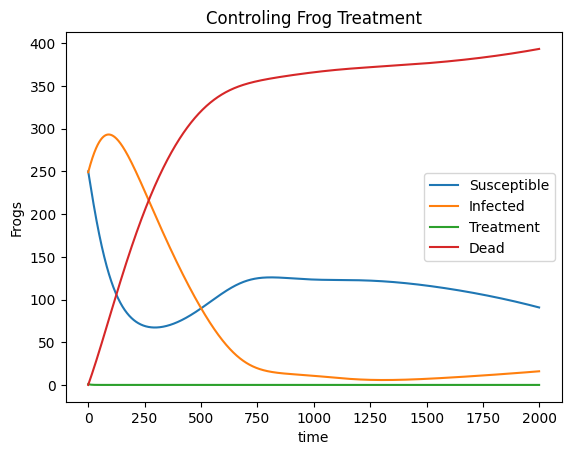

In [22]:
# PLOTS
sol.y.shape
plt.plot(sol.y[0], label="Susceptible")
plt.plot(sol.y[1], label="Infected")
plt.plot(sol.y[2], label="Treatment")
plt.plot(500 - sol.y[0] - sol.y[1] - sol.y[2], label="Dead")
plt.legend()
plt.title("Controling Frog Treatment")
plt.xlabel("time")
plt.ylabel("Frogs")
# plt.ylim(0, 100)
plt.show()

Text(0, 0.5, 'spending')

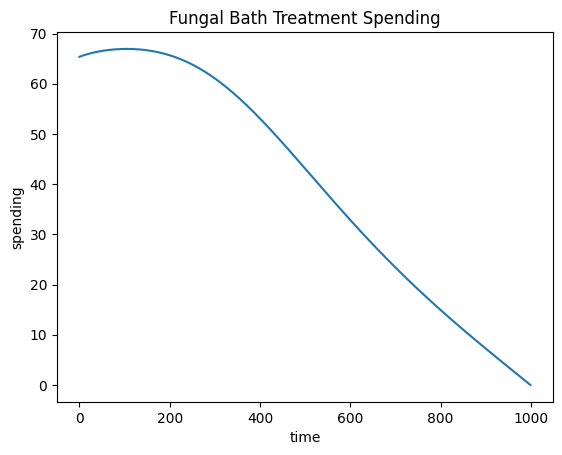

In [12]:
u_sym = u_symbolic.subs(parameters)
u_function = sy.lambdify((x, lam), u_sym, modules="numpy")

# plot the control parameters
plt.plot(u_function(sol.y[:3], sol.y[3:]))
plt.title("Fungal Bath Treatment Spending")
plt.xlabel("time")
plt.ylabel("spending")

### Possible Next Steps

- iteratively solve $x$ forward and $\lambda$ backward
- grid search over initial values


In [13]:
from model import Model

model = Model(seasonal=False, no_dead=True, const_u1=0)
f = model.sy_f
display(f)

Matrix([
[-3.5e-5*I*S + 1.0*I*u2/(100*I + 5000) + 0.1*T1],
[3.5e-5*I*S - 1.0*I*u2/(100*I + 5000) - 0.003*I],
[                                       -0.1*T1]])